<a href="https://colab.research.google.com/github/snamazova/centaur_evaluation/blob/main/repetetive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random

class ActionModel:
    def __init__(self, actions, p_stay):
        self.actions = actions  # List of possible actions, e.g.,
        self.p_stay = p_stay    # Probability of staying with the same action, e.g., 0.7
        self.current_action = random.choice(actions)  # Start with a random action

    def next_action(self):
      if random.random() < self.p_stay:
        return self.current_action  # Repeat the same action
      else:
          other_actions = [a for a in self.actions if a != self.current_action]
          self.current_action = random.choice(other_actions) if other_actions else self.current_action
          return self.current_action  # Choose a new action, or stay if no others


    def simulate(self, steps):
        return [self.next_action() for _ in range(steps)]  # Simulate for a number of steps

In [ ]:
import random

random.seed(42)

# Number of trials
num_trials = 100

# Define the timeline
timeline = []
for i in range(num_trials):
    while True:
        if i < (num_trials / 2):
            bandit_1_reward = random.choices([1, 0], weights=[0.8, 0.2])[0]
            bandit_2_reward = random.choices([1, 0], weights=[0.2, 0.8])[0]
        else:
            bandit_1_reward = random.choices([1, 0], weights=[0.2, 0.8])[0]
            bandit_2_reward = random.choices([1, 0], weights=[0.8, 0.2])[0]

        if not (bandit_1_reward == 0 and bandit_2_reward == 0):
            break

    timeline.append({
        "bandit_1": {"color": "orange", "value": bandit_1_reward},
        "bandit_2": {"color": "blue", "value": bandit_2_reward}
    })

In [ ]:
def parse_timeline(timeline):
    rewards_per_trial = []
    for trial in timeline:
        # Extract rewards for bandit_1 and bandit_2
        reward_1 = trial['bandit_1']['value']
        reward_2 = trial['bandit_2']['value']
        rewards_per_trial.append([reward_1, reward_2])
    return rewards_per_trial

In [ ]:
import pandas as pd
import numpy as np

# Lists to store data
trials = []
choices = []
rewards = []
scores = []
model_ids = []

# Number of model runs
model_runs = 20
num_trials = 100

# Simulate multiple model runs
for model_id in range(model_runs):
    total_reward = 0  # Reset cumulative reward for each model run
    np.random.seed(model_id)  # Change NumPy random seed
    random.seed(model_id)  # Change Python random seed
    bandits=["bandit_1","bandit_2"]

    # Randomly assign initial action with 50% chance for each bandit
    initial_action = random.choice(bandits)
    action_agent = ActionModel(actions=bandits, p_stay=1)
    action_agent.current_action = initial_action


    for trial in range(1, num_trials + 1):
        chosen_action = action_agent.next_action()  # Pick an action

        # Simulate outcome (Win or Loss)
        outcome = int(timeline[trial - 1][chosen_action]["value"] == 1)  # Win (1) or Loss (0)
        total_reward += outcome  # Update cumulative reward

        # Store data
        trials.append(trial)
        choices.append(chosen_action)
        rewards.append(outcome)
        scores.append(total_reward)
        model_ids.append(model_id)

In [ ]:
# Create DataFrame
df = pd.DataFrame({
    "trial": trials,
    "choice": choices,
    "reward": rewards,
    "score": scores,
    "model_id": model_ids
})


In [ ]:
df

,trial,choice,reward,score,model_id
0,1,bandit_2,1,1,0
1,2,bandit_2,0,1,0
2,3,bandit_2,0,1,0
3,4,bandit_2,1,2,0
4,5,bandit_2,1,3,0
...,...,...,...,...,...
1995,96,bandit_1,0,58,19
1996,97,bandit_1,0,58,19
1997,98,bandit_1,0,58,19
1998,99,bandit_1,0,58,19


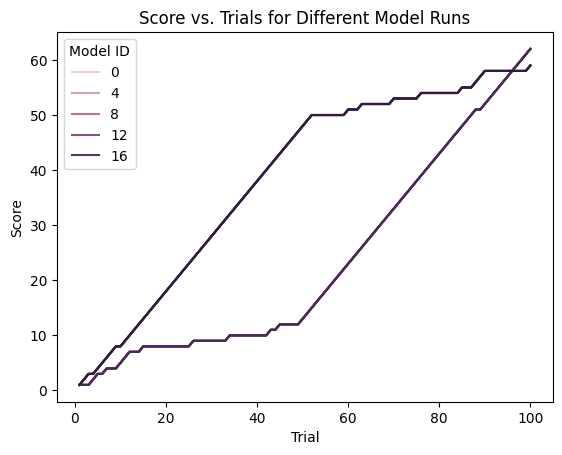

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Group data by 'model_id' and calculate the mean score for each trial
grouped_df = df.groupby(['model_id', 'trial'])['score'].mean().reset_index()

# Create the plot using seaborn
sns.lineplot(x='trial', y='score', hue='model_id', data=grouped_df)

# Customize the plot
plt.title('Score vs. Trials for Different Model Runs')
plt.xlabel('Trial')
plt.ylabel('Score')
plt.legend(title='Model ID')

# Show the plot
plt.show()

    trial  Choice_Rate_Bandit1  Choice_Rate_Bandit2
0       1                 0.55                 0.45
1       2                 0.55                 0.45
2       3                 0.55                 0.45
3       4                 0.55                 0.45
4       5                 0.55                 0.45
..    ...                  ...                  ...
95     96                 0.55                 0.45
96     97                 0.55                 0.45
97     98                 0.55                 0.45
98     99                 0.55                 0.45
99    100                 0.55                 0.45

[100 rows x 3 columns]


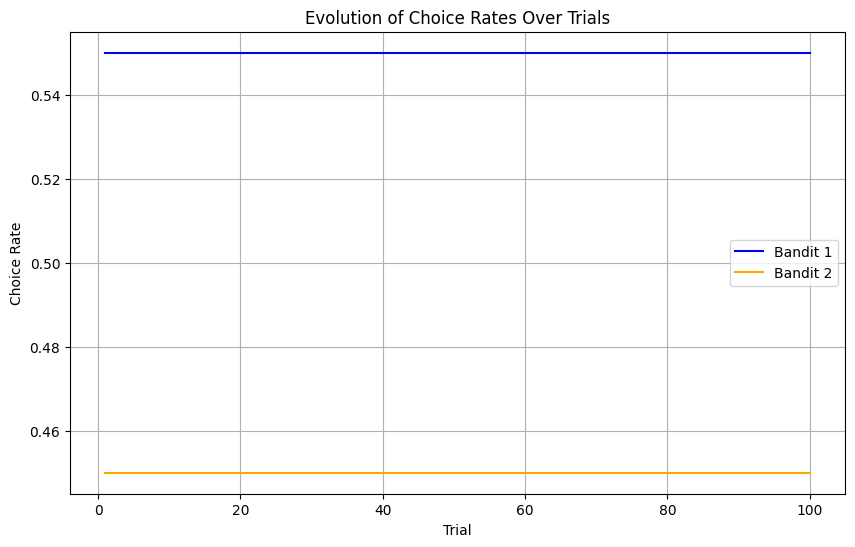

In [ ]:
# Create bandit1_chosen column (1 if choice = 0, 0 otherwise)
df['bandit1_chosen'] = (df['choice'] == 'bandit_1').astype(int)
# Group by trial and sum the bandit1_chosen column
trial_counts = df.groupby('trial')['bandit1_chosen'].agg(['sum', 'count']).reset_index()

# Rename columns for clarity
trial_counts.rename(columns={'sum': 'Bandit1_Chosen', 'count': 'Total_Choices'}, inplace=True)

# Calculate Bandit 2 choices
trial_counts['Bandit2_Chosen'] = trial_counts['Total_Choices'] - trial_counts['Bandit1_Chosen']

# Calculate choice rates
trial_counts['Choice_Rate_Bandit1'] = trial_counts['Bandit1_Chosen'] / trial_counts['Total_Choices']
trial_counts['Choice_Rate_Bandit2'] = trial_counts['Bandit2_Chosen'] / trial_counts['Total_Choices']

# View results
print(trial_counts[['trial', 'Choice_Rate_Bandit1', 'Choice_Rate_Bandit2']])

# Plot the evolution of choice rates
plt.figure(figsize=(10, 6))
plt.plot(trial_counts['trial'], trial_counts['Choice_Rate_Bandit1'], label='Bandit 1', color='blue')
plt.plot(trial_counts['trial'], trial_counts['Choice_Rate_Bandit2'], label='Bandit 2', color='orange')
plt.xlabel('Trial')
plt.ylabel('Choice Rate')
plt.title('Evolution of Choice Rates Over Trials')
plt.legend()
plt.grid()
plt.show()

In [ ]:
df.to_csv('/content/drive/MyDrive/centaur/repetetive_randomized.csv')

In [ ]:
rw_data=pd.read_csv('/content/drive/MyDrive/centaur/reversal_learning/rw_reversal_learning.csv')

In [ ]:
rw_data

,trial,choice,reward,cumulative_reward,model_id
0,1,0,1,1,83811
1,2,1,0,1,83811
2,3,0,1,2,83811
3,4,1,1,3,83811
4,5,0,1,4,83811
...,...,...,...,...,...
3195,96,1,1,83,28894
3196,97,1,1,84,28894
3197,98,1,1,85,28894
3198,99,1,1,86,28894


In [ ]:
import numpy as np

def nll_repetitive_model(df, p_stay):
    """
    Compute NLL of a model that predicts repeating the previous choice with probability p_stay.

    Parameters:
    - df (pd.DataFrame): Must contain a 'choice' column.
    - p_stay (float): Probability of staying with the same choice.

    Returns:
    - Negative log-likelihood (float)
    """
    choices = df['choice'].tolist()
    if len(choices) < 2:
        return 0.0  # Not enough data to compute NLL

    loglik = 0.0
    prev_choice = choices[0]

    for choice in choices[1:]:
        prob = p_stay if choice == prev_choice else (1 - p_stay)
        # Avoid log(0) issues
        prob = np.clip(prob, 1e-12, 1.0)
        loglik += np.log(prob)
        prev_choice = choice

    return -loglik


In [ ]:
from scipy.optimize import minimize

def fit_p_stay(df, initial_guess=0.5):
    """
    Fit the p_stay parameter by minimizing NLL.

    Parameters:
    - df (pd.DataFrame): Data containing 'choice' column
    - initial_guess (float): Starting point for optimizer

    Returns:
    - Fitted p_stay (float)
    """
    result = minimize(
        lambda p: nll_repetitive_model(df, p[0]),
        x0=[initial_guess],
        bounds=[(0.0, 1.0)],
        method='L-BFGS-B'
    )

    return result.x[0]


In [ ]:
# Fit the model
best_p_stay = fit_p_stay(rw_data)
print("Fitted p_stay:", best_p_stay)


Fitted p_stay: 0.74460797341065


In [ ]:
val_negLL=nll_repetitive_model(rw_data,best_p_stay)

print("Average log loss per trial:", val_negLL / len(rw_data))

Average log loss per trial: 0.5680044742188777


In [ ]:
import json

data_to_save = {
    "average_log_loss_per_trial": val_negLL / len(rw_data)
}

# Define the path to save the JSON file in Google Drive
json_file_path = ('/content/drive/MyDrive/centaur/reversal_learning/repetetive_metrics.json')

# Save the data as a JSON file
with open(json_file_path, 'w') as f:
    json.dump(data_to_save, f)

print(f"Average log loss per trial saved to {json_file_path}")


Average log loss per trial saved to /content/drive/MyDrive/centaur/reversal_learning/repetetive_metrics.json
